# XOR

In [2]:
import numpy as np
#데이터 준비
X=np.array([[0,0],[0,1],[1,0],[1,1]])
y=np.array([[0],[1],[1],[0]])
#모델의 형상
#입력뉴런과 출력뉴런의 갯수는 프로그래머가 정할 수 없다.
#입력뉴런의 갯수는 입력 데이터의 피처수
#출력뉴런의 갯수는 타겟데이터의 값에 따라 결정
#은닉층의 계층수와 뉴런의 수는 프로그래머가 정한다.
in_n=2
h_n=2
out_n=1
#예측값 준비(초기 가중치)
W1=2*np.random.random((in_n,h_n))-1
W2=2*np.random.random((h_n,out_n))-1

In [3]:
X.shape,W1.shape,W2.shape,y.shape

((4, 2), (2, 2), (2, 1), (4, 1))

In [4]:
#활성화 함수
def act_f(z):#시그모이드 활성화 함수
    return 1/(1+np.exp(-z))
def act_f_d(x):#시그모이드 활성화 함수 도함수
    return x*(1-x)

순전파 연산(초기 가중치를 이용한)

In [5]:
#모델 형성
#입력->은닉
#입력층
l_in=X
#1번 계층 
z1=l_in@W1#입력값과 히든층의 가중치 내적연산
h1=act_f(z1)#z값 활성화 함수 연산
#은닉->출력
#2번 계층
z2=h1@W2#히든층출력과 출력층의 가중치 내적연산
l_out=act_f(z2)#결과 출력을 위한 연산 (출력함수==활성화함수)
print("출력:\n",l_out)#예측값

출력:
 [[0.58772277]
 [0.57379419]
 [0.57959569]
 [0.5659528 ]]


오차

In [6]:
out_err=y-l_out
out_err

array([[-0.58772277],
       [ 0.42620581],
       [ 0.42040431],
       [-0.5659528 ]])

오차 역전파

In [7]:
#출력오차
out_err=y-l_out
#출력 오차 전달
l_out_d=act_f_d(l_out)*out_err
#히든오차
h_err=l_out_d@W2.T
#히든 오차 전달
h_l_d=act_f_d(h1)*h_err
#최적화
W2-=0.2*(h1.T@l_out_d)
W1-=0.2*(l_in.T@h_l_d)

통합 정리

In [8]:
import numpy as np
#데이터 준비
X=np.array([[0,0],[0,1],[1,0],[1,1]])
y=np.array([[0],[1],[1],[0]])
#모델의 형상
in_n=2
h_n=3
out_n=1
#예측값 준비(초기 가중치)
W1=2*np.random.random((in_n,h_n))-1
W2=2*np.random.random((h_n,out_n))-1
#활성화 함수
def act_f(z):
    return 1/(1+np.exp(-z))
#도함수
def act_f_d(x):
    return x*(1-x)
#순방향 연산
l_in=X
z1=l_in@W1
h1=act_f(z1)
z2=h1@W2
l_out=act_f(z2)
print("학습전\n",l_out>=0.5)

학습률=0.5
반복수=10000
#학습
for i in range(반복수):
    #예측값 도출
    l_in=X
    z1=l_in@W1
    h1=act_f(z1)
    z2=h1@W2
    l_out=act_f(z2)
    #오차 도출
    out_err=l_out-y
    #오차 역전파
    l_out_d=act_f_d(l_out)*out_err
    h_err=l_out_d@W2.T
    h_l_d=act_f_d(h1)*h_err
    #가중치 연산
    W2 -= 학습률*(h1.T@l_out_d)
    W1 -= 학습률*(l_in.T@h_l_d)
    
l_in=X
z1=l_in@W1
h1=act_f(z1)
z2=h1@W2
l_out=act_f(z2)    
print("학습후\n",l_out>=0.5)

학습전
 [[ True]
 [ True]
 [ True]
 [ True]]
학습후
 [[False]
 [ True]
 [ True]
 [False]]


In [9]:
h1.T.shape,l_out_d.shape

((3, 4), (4, 1))

In [10]:
l_in.T.shape,h_l_d.shape

((2, 4), (4, 3))

In [11]:
X=np.array([[0,0],[0,1],[1,0],[1,1]])
y=np.array([0,1,1,0])

In [12]:
class Two_net:
    def __init__(self,hidden_units=10,lr=0.1):
        self.hidden_units=hidden_units
        self.w1=None
        self.b1=None
        self.w2=None
        self.b2=None
        self.losses=[]
        self.lr=lr
    def forpass(self,X):
        z1=X@self.w1+self.b1
        a1=self.act_f_relu(z1)
        z2=a1@self.w2+self.b2
        return z1,a1,z2
        
    def act_f_relu(self,z):
        return np.maximum(0,z)
        
    def act_f_sigmoid(self,z):
        z=np.clip(z,-100,None)
        return 1/(1+np.exp(-z))

    def backpass(self,X,a1,z1,z2,y):
        py=self.act_f_sigmoid(z2)
        err_output = py-y

        w2_g = (a1.T@err_output)/len(X)
        b2_g = np.mean(err_output)

        da1 = err_output@self.w2.T
        dz1 = da1*(z1>0)

        w1_g = (X.T@dz1) /len(X)
        b1_g = np.mean(dz1,axis=0)

        return w1_g,b1_g,w2_g,b2_g
    def fit(self,X,y,epoch=1000,batch_size=4):
        n_samples,n_features = X.shape
        np.random.seed(42)
        #가중치 초기화 He 초기화
        self.w1 = np.random.randn(n_features,self.hidden_units)*np.sqrt(2./n_features)
        self.b1 = np.zeros(self.hidden_units)
        self.w2 = np.random.randn(self.hidden_units,1)*np.sqrt(2./self.hidden_units)
        self.b2 = 0

        for _ in range(epoch):
            idx=np.random.permutation(n_samples)
            X_sf=X[idx]
            y_sf=y[idx].reshape(-1,1)
            loss=0
            for start in range(0,n_samples,batch_size):
                end = start+batch_size
                X_batch = X_sf[start:end]
                y_batch = y_sf[start:end]

                z1,a1,z2 = self.forpass(X_batch)
                py = self.act_f_sigmoid(z2)

                w1_g,b1_g,w2_g,b2_g = self.backpass(X_batch,a1,z1,z2,y_batch)

                self.w1 -= self.lr*w1_g
                self.b1 -= self.lr*b1_g
                self.w2 -= self.lr*w2_g
                self.b2 -= self.lr*b2_g

                py = np.clip(py,1e-10,1-1e-10)
                batch_loss=-np.mean(y_batch*np.log(py)+(1-y_batch)*np.log(1-py))
                loss+= batch_loss*len(X_batch)
            self.losses.append(loss/n_samples)
            
    def predict(self,X):
        _,_,z2=self.forpass(X)
        py = self.act_f_sigmoid(z2)
        return (py>0.5).astype(int)
    def score(self,X,y):
        return np.mean(self.predict(X)==y)

예측값: [0 1 1 0]
실제값: [0 1 1 0]
정확도 1.0


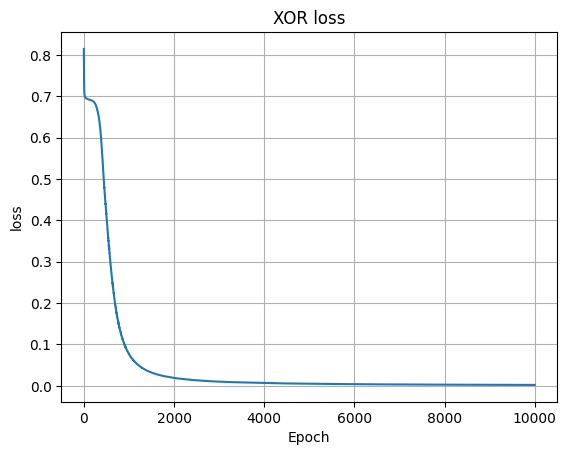

In [13]:
import matplotlib.pyplot as plt
X=np.array([[0,0],[0,1],[1,0],[1,1]])
y=np.array([[0],[1],[1],[0]])

m=Two_net(4)
m.fit(X,y,epoch=10000,batch_size=4)

py=m.predict(X)
print("예측값:",py.reshape(-1))
print("실제값:",y.reshape(-1))
print("정확도",m.score(X,y))

plt.plot(m.losses)
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.title('XOR loss')
plt.grid(True)
plt.show()

In [14]:
from keras import models
from keras import layers
from keras import losses
from keras import optimizers
from keras import utils,preprocessing,activations

In [15]:
from keras.models import Sequential,Model
from keras.layers import Input,Dense
from keras.losses import binary_crossentropy,categorical_crossentropy,mean_squared_error,mean_absolute_error
from keras.optimizers import SGD

In [16]:
X.shape

(4, 2)

In [17]:
m=Sequential()#케이스
m.add(Input(shape=(2,)))
m.add(Dense(3,activation='relu'))
m.add(Dense(1,activation='sigmoid'))
m.compile(loss='binary_crossentropy')
m.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
hy=m.fit(X,y,epochs=1000,batch_size=16)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - loss: 0.7565
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.7544
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.7529
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7516
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.7505
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.7495
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7486
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7477
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7468
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7460
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7452
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7445
Epoch 13/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7437
Epoch 14/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7430
Epoch 15/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.7423
Epo

In [19]:
m.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


array([[0.3141018 ],
       [0.7464395 ],
       [0.7347777 ],
       [0.21600193]], dtype=float32)

In [20]:
from keras.models import Sequential
from keras.layers import Dense,Input
from keras.losses import binary_crossentropy, categorical_crossentropy, mean_squared_error,sparse_categorical_crossentropy
from keras.datasets import mnist,fashion_mnist,imdb

In [21]:
data=mnist.load_data()

In [22]:
tr_data,tt_data=data

In [23]:
X,y=tr_data

In [24]:
X.shape,y.shape

((60000, 28, 28), (60000,))

In [25]:
import numpy as np

In [26]:
np.unique(y)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [27]:
X.reshape(-1,28,28,1).shape

(60000, 28, 28, 1)

In [28]:
X=X.reshape(-1,28*28)

In [29]:
X.shape,y.shape

((60000, 784), (60000,))

In [30]:
y.shape

(60000,)

In [31]:
from keras.utils import to_categorical
e_y=to_categorical(y)

In [32]:
e_y.shape

(60000, 10)

In [33]:
m=Sequential()
m.add(Input(shape=(784,)))#입력층
m.add(Dense(10,activation='relu'))#은닉층
m.add(Dense(10,activation='softmax'))#출력층
m.compile(loss='categorical_crossentropy')#반드시 y값이 인코딩 되어야 사용이 가능하다.

In [34]:
X.shape,e_y.shape

((60000, 784), (60000, 10))

In [35]:
m.fit(X,e_y)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 278us/step - loss: 3.6069


In [36]:
m=Sequential()
m.add(Input(shape=(784,)))#입력층
m.add(Dense(10,activation='relu'))#은닉층
m.add(Dense(10,activation='softmax'))#출력층
m.compile(loss='sparse_categorical_crossentropy')

In [37]:
m.fit(X,y)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 259us/step - loss: 4.0766


In [38]:
m.predict(X[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


array([[0.12738329, 0.03935442, 0.12582378, 0.13118228, 0.12227438,
        0.11550664, 0.05425258, 0.03527841, 0.12271668, 0.12622754]],
      dtype=float32)

In [39]:
m.evaluate(X,y)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 231us/step - loss: 1.7021


1.7061395645141602

In [40]:
np.argmax(m.predict(X[:1]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


3

In [41]:
y[0]

5

# Q1 mnist(필기체 인식용 데이터) 분류기 만들기(완전연결계층을 이용하여) 

0. 작업준비

In [42]:
from keras.models import Sequential
from keras.layers import Dense, Input 
from keras.utils import to_categorical
from keras.datasets import mnist

1. 데이터 수집

In [43]:
(tr_x,tr_y),(tt_x,tt_y)=mnist.load_data()

2. 데이터 전처리

In [44]:
e_X=tr_x.reshape(-1,28*28)
e_y=to_categorical(tr_y)

3. 모델 설계 학습

In [45]:
#모델 설계
m=Sequential()
m.add(Input(shape=(784,)))#입력층
m.add(Dense(10,activation='relu'))#은닉층
m.add(Dense(10,activation='softmax'))#출력층
m.compile(loss='categorical_crossentropy')

In [46]:
#모델 학습
hy=m.fit(e_X,e_y,epochs=100)

Epoch 1/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 257us/step - loss: 3.6266
Epoch 2/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 256us/step - loss: 2.3012
Epoch 3/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 257us/step - loss: 2.2371
Epoch 4/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 256us/step - loss: 1.9596
Epoch 5/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 267us/step - loss: 1.8557
Epoch 6/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 264us/step - loss: 1.7071
Epoch 7/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 267us/step - loss: 1.5742
Epoch 8/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 262us/step - loss: 1.5225
Epoch 9/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 270us/step - loss: 1.4300
Epoch 10/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 266us/step - loss: 1.3793
Epoch 11/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 260us/step - loss: 1.3083
Epoch 12/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 259us/step - loss: 1.2501
Epoch 13/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 263us/step - loss: 1.1825
Epoch 14/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 259us/step - 

4. 모델 검증 및 테스트

In [47]:
import matplotlib.pyplot as plt

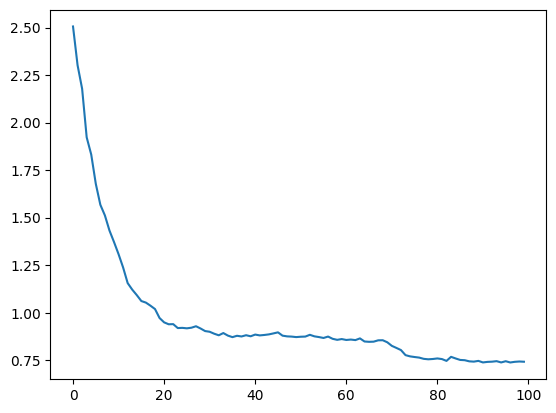

In [48]:
plt.plot(hy.history['loss'])

In [49]:
m.evaluate(e_X,e_y)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 240us/step - loss: 0.7205


0.716312825679779

In [50]:
#0. 작업준비
#데이터 분석
#1. 데이터 수집
#2. 데이터 전처리(EDA)
#3. 모델설계
#4. 모델 학습
#5. 모델 검증 및 테스트

In [51]:
#0. 작업 준비
import numpy as np
import pandas as pd
#데이터 분할
from sklearn.model_selection import train_test_split
#모델 모듈(딥러닝)
from keras.models import Sequential
from keras.layers import Input,Dense,Conv2D,MaxPooling2D,Dropout,SimpleRNN,LSTM,GRU,BatchNormalization
from keras.optimizers import Adam,RMSprop,SGD,Adagrad
from keras.losses import binary_crossentropy,categorical_crossentropy,sparse_categorical_crossentropy,mean_squared_error
#모델 학습
from keras.callbacks import EarlyStopping,ModelCheckpoint
#모델 로드
from keras.models import load_model
#성능검토 
from sklearn.metrics import r2_score,classification_report,f1_score,mean_squared_error

In [52]:
from keras.datasets import mnist

In [53]:
#1. 데이터 수집
(tr_x,tr_y),(tt_x,tt_y)=mnist.load_data()

In [54]:
tr_x.shape,tr_y.shape,tt_x.shape,tt_y.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

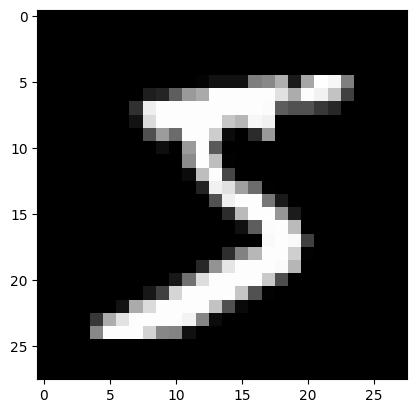

In [55]:
#2.데이터 전처리(EDA)
import matplotlib.pyplot as plt 
plt.imshow(tr_x[0],cmap='gray')#이미지는 화소당 일반적(RGB)으로 0~255 값을 갖는다

In [56]:
(X,y),(_,_)=mnist.load_data()
x_data,tt_x,y_data,tt_y=train_test_split(X,y,train_size=0.7,stratify=y)
tr_x,val_x,tr_y,val_y=train_test_split(x_data,y_data,train_size=0.8,stratify=y_data)

In [57]:
tr_x.shape,tt_x.shape,val_x.shape,tr_y.shape,tt_y.shape,val_y.shape

((33600, 28, 28), (18000, 28, 28), (8400, 28, 28), (33600,), (18000,), (8400,))

In [58]:
e_tr_x=tr_x.reshape(-1,28*28)
e_tt_x=tt_x.reshape(-1,28*28)
e_val_x=val_x.reshape(-1,28*28)

In [59]:
e_tr_y=to_categorical(tr_y)
e_tt_y=to_categorical(tt_y)
e_val_y=to_categorical(val_y)

In [60]:
e_tr_x.shape,e_tt_x.shape,e_val_x.shape,e_tr_y.shape,e_tt_y.shape,e_val_y.shape

((33600, 784), (18000, 784), (8400, 784), (33600, 10), (18000, 10), (8400, 10))

In [61]:
#3. 모델 설계
m=Sequential()
m.add(Input(shape=e_tr_x.shape[1:]))
m.add(Dense(100,activation='relu'))
m.add(Dense(100,activation='relu'))
m.add(Dense(10,activation='softmax'))
m.summary()      

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,610 (350.04 KB)

 Trainable params: 89,610 (350.04 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
#학습 규칙 제시
m.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['acc'])

In [72]:
#모델 학습
hy=m.fit(e_tr_x,e_tr_y,validation_data=(e_val_x,e_val_y),epochs=10)

Epoch 1/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 678us/step - acc: 0.9835 - loss: 0.0571 - val_acc: 0.9607 - val_loss: 0.2667
Epoch 2/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 702us/step - acc: 0.9855 - loss: 0.0555 - val_acc: 0.9596 - val_loss: 0.3011
Epoch 3/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 681us/step - acc: 0.9837 - loss: 0.0584 - val_acc: 0.9581 - val_loss: 0.2988
Epoch 4/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 702us/step - acc: 0.9853 - loss: 0.0555 - val_acc: 0.9607 - val_loss: 0.2984
Epoch 5/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 698us/step - acc: 0.9863 - loss: 0.0546 - val_acc: 0.9580 - val_loss: 0.3033
Epoch 6/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 709us/step - acc: 0.9868 - loss: 0.0519 - val_acc: 0.9621 - val_loss: 0.2869
Epoch 7/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 686us/step - acc: 0.9888 - loss: 0.0392 - val_acc: 0.9608 - val_loss: 0.3141
Epoch 8/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 700us/step - acc: 0.9872 - loss: 0.0490 - val_acc: 0.9543 - val_loss: 0.3349
Epoch 9/10
1050/1050 ━━━

In [64]:
#모델 테스트 및 검증
m.evaluate(e_tr_x,e_tr_y)

1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 329us/step - acc: 0.9746 - loss: 0.0866


[0.09079637378454208, 0.9736904501914978]

In [65]:
m.evaluate(e_tt_x,e_tt_y)

563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 318us/step - acc: 0.9604 - loss: 0.1782


[0.20513620972633362, 0.9558888673782349]

In [66]:
m.evaluate(e_val_x,e_val_y)

263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 364us/step - acc: 0.9535 - loss: 0.2317


[0.22407908737659454, 0.9530952572822571]

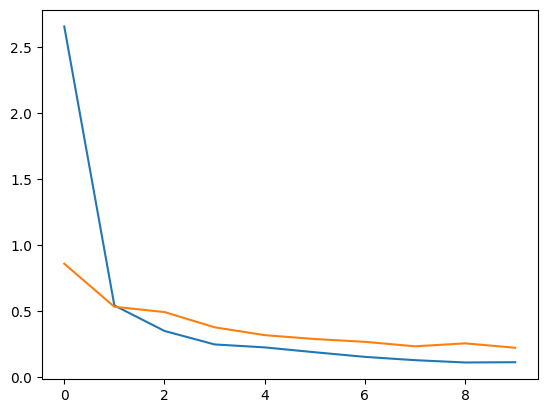

In [67]:
plt.plot(hy.history['loss'])
plt.plot(hy.history['val_loss'])

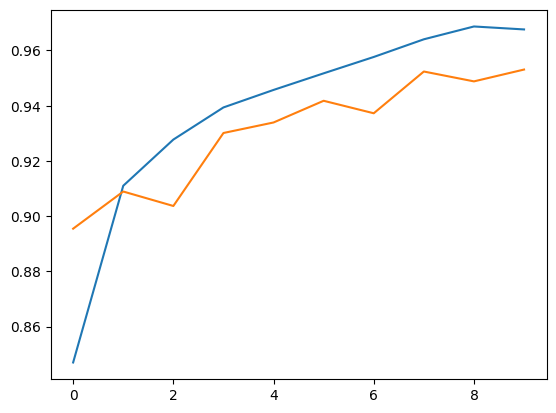

In [68]:
plt.plot(hy.history['acc'])
plt.plot(hy.history['val_acc'])

In [73]:
hy2=m.fit(e_tr_x,e_tr_y,validation_data=(e_val_x,e_val_y),epochs=10)

Epoch 1/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 675us/step - acc: 0.9896 - loss: 0.0480 - val_acc: 0.9600 - val_loss: 0.3599
Epoch 2/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 709us/step - acc: 0.9886 - loss: 0.0502 - val_acc: 0.9620 - val_loss: 0.3412
Epoch 3/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 700us/step - acc: 0.9909 - loss: 0.0382 - val_acc: 0.9590 - val_loss: 0.4202
Epoch 4/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 725us/step - acc: 0.9895 - loss: 0.0505 - val_acc: 0.9620 - val_loss: 0.4177
Epoch 5/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 714us/step - acc: 0.9886 - loss: 0.0486 - val_acc: 0.9606 - val_loss: 0.3549
Epoch 6/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 732us/step - acc: 0.9900 - loss: 0.0474 - val_acc: 0.9568 - val_loss: 0.4651
Epoch 7/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 732us/step - acc: 0.9873 - loss: 0.0547 - val_acc: 0.9583 - val_loss: 0.3952
Epoch 8/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 717us/step - acc: 0.9902 - loss: 0.0386 - val_acc: 0.9606 - val_loss: 0.4175
Epoch 9/10
1050/1050 ━━━

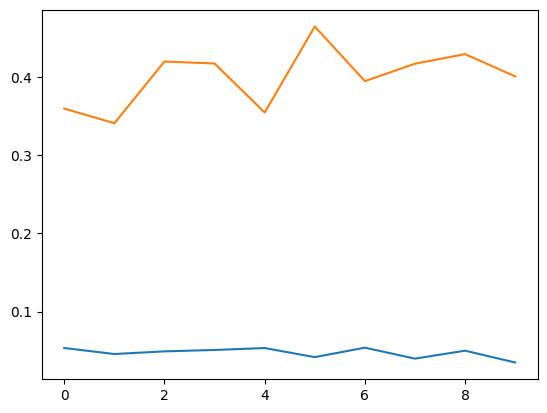

In [74]:
plt.plot(hy2.history['loss'])
plt.plot(hy2.history['val_loss'])

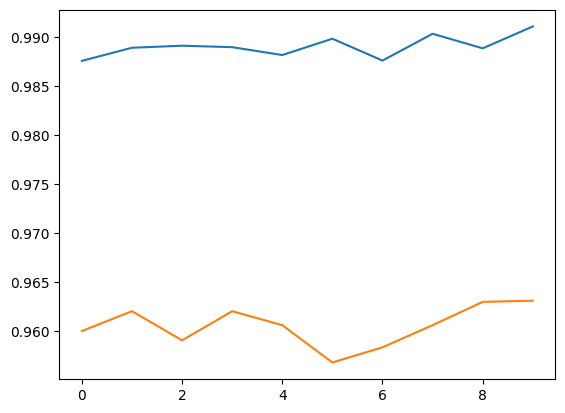

In [75]:
plt.plot(hy2.history['acc'])
plt.plot(hy2.history['val_acc'])

# Q1 mnist(필기체 인식용 데이터) 분류기 만들기(완전연결계층을 이용하여)